# AI-Assisted Heart Disease Prediction Project

**Course:** Artificial Intelligence | Final Examination  
**Research name:** AI-Assisted Heart Disease Prediction Project  
**Scenario:** HealthPlus Hospital needs an AI system to predict heart disease.  
**Live Streamlit app:** https://heartdiseaseaimllabfinal.streamlit.app/

This notebook is the final exam notebook. It documents the dataset, EDA, preprocessing, feature engineering, model training, model evaluation, model interpretation, AI-assisted reflection, limitations, ethics, and deployment explanation.


## Final Submission Files

- `Heart_Disease_Final_Exam.ipynb` - final notebook
- `final_exam_heart_disease.py` - full reproducible Python script
- `Final_Report_Heart_Disease.pdf` - formatted final report
- `AI_Prompt_History.txt` - AI prompt history and reflection notes
- `heart_disease_cleaned.csv` - cleaned and feature-engineered dataset
- `streamlit_app.py` - deployed Streamlit prediction app
- `output/model_metrics.json` - saved model evaluation metrics
- `output/top_10_feature_importance.csv` - saved feature-importance table


## Task 1: Dataset Understanding

The dataset used in this project is the **UCI Cleveland Heart Disease dataset**. The original target column is `target_raw`. A value of `0` means no heart disease, while values `1`, `2`, `3`, and `4` mean the patient has heart disease. For this project, the target was converted into a binary classification target named `target`.

**Problem type:** Binary classification.

**Important expected features:** chest pain type (`cp`), exercise induced angina (`exang`), oldpeak, maximum heart rate (`thalach`), number of major vessels (`ca`), thalassemia result (`thal`), age, and ST slope.

**Main challenges:** small dataset size and missing values in `ca` and `thal`.


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target_raw']
df = pd.read_csv('heart_disease_uci_raw.csv', header=None, names=columns, na_values='?')
print('Raw dataset shape:', df.shape)
print('Total missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
df.head()


Raw dataset shape: (303, 14)
Total missing values: 6
Duplicate rows: 0


 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target_raw
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0           0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0           2
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0           1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0           0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0   3.0           0

## Task 2: Exploratory Data Analysis

EDA was used to understand the dataset shape, missing values, class balance, and important feature relationships. The figures below were generated by the project script and saved under `output/figures/`.


In [2]:
summary = pd.DataFrame({
    'Item': ['Raw rows and columns', 'Clean rows and columns', 'Missing values in raw data', 'Duplicate rows', 'Class distribution'],
    'Result': [f'{df.shape[0]} rows, {df.shape[1]} columns', f'{clean_df.shape[0]} rows, {clean_df.shape[1]} columns', int(df.isna().sum().sum()), int(df.duplicated().sum()), str(clean_df['target'].value_counts().sort_index().to_dict())]
})
summary


                      Item               Result
      Raw rows and columns 303 rows, 14 columns
    Clean rows and columns 303 rows, 21 columns
Missing values in raw data                    6
            Duplicate rows                    0
        Class distribution     {0: 164, 1: 139}

### Figure 1


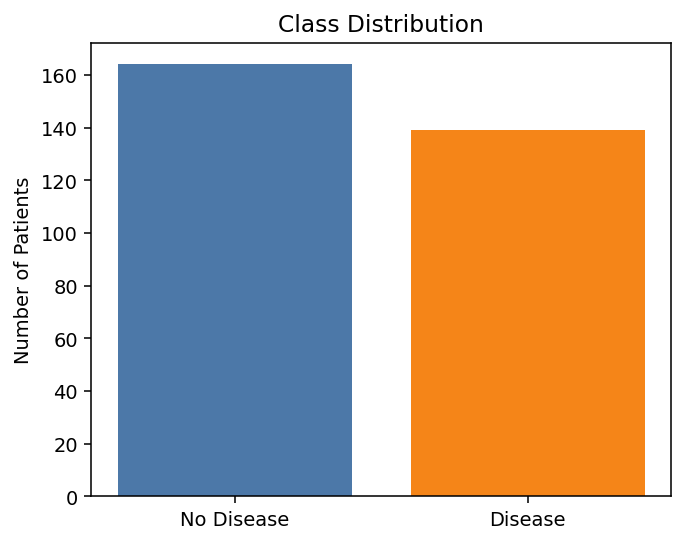

In [3]:
from IPython.display import Image, display
display(Image('output/figures/01_class_distribution.png'))


Figure 1: Class distribution. This chart compares patients with no heart disease and patients with heart disease. The classes are fairly balanced, so accuracy is useful, but recall and F1-score are still important for medical prediction.


### Figure 2


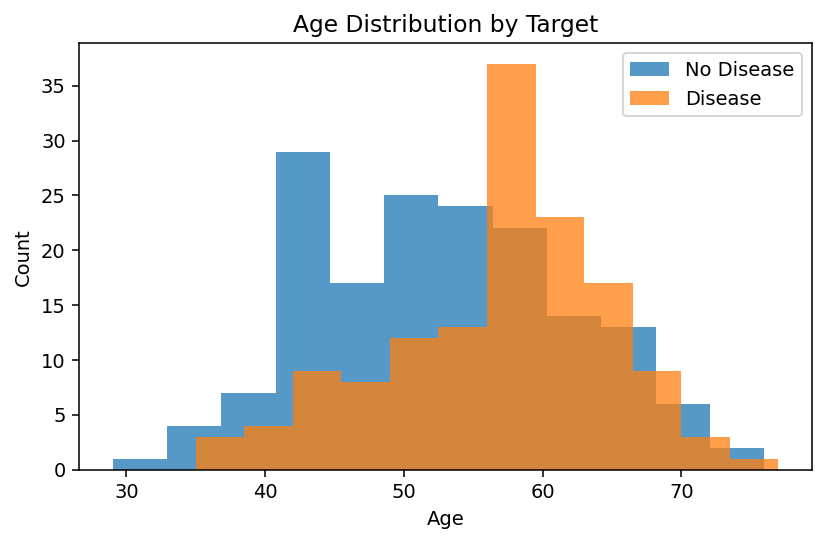

In [4]:
from IPython.display import Image, display
display(Image('output/figures/02_age_distribution.png'))


Figure 2: Age distribution by target. Heart disease cases appear more common in older age ranges. This supports using age and the engineered age_group feature.


### Figure 3


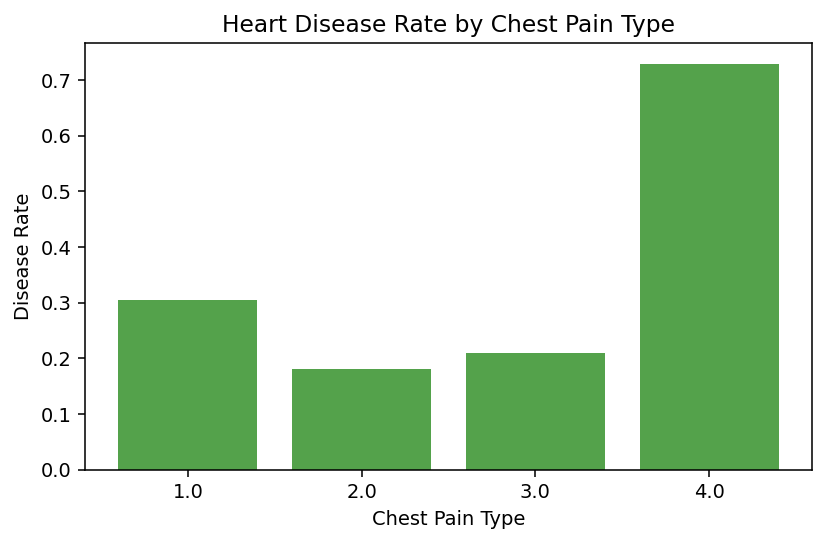

In [5]:
from IPython.display import Image, display
display(Image('output/figures/03_chest_pain_rate.png'))


Figure 3: Heart disease rate by chest pain type. Some chest pain categories have higher disease rates, so chest pain type is a useful categorical predictor.


### Figure 4


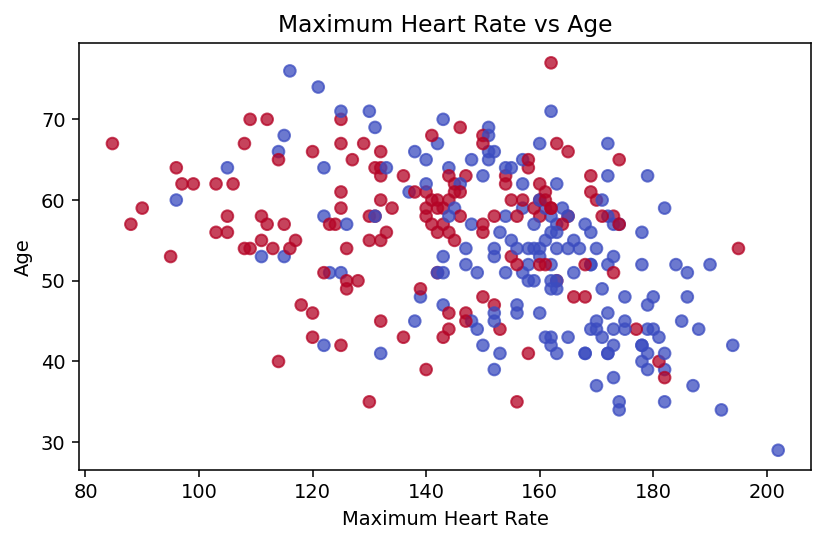

In [6]:
from IPython.display import Image, display
display(Image('output/figures/04_thalach_age_scatter.png'))


Figure 4: Maximum heart rate versus age. Older patients and patients with lower maximum heart rate often show higher risk patterns.


### Figure 5


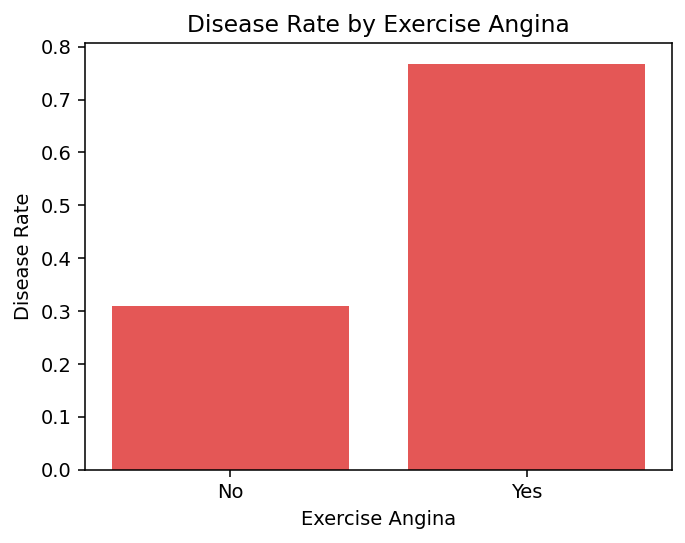

In [7]:
from IPython.display import Image, display
display(Image('output/figures/05_exang_rate.png'))


Figure 5: Disease rate by exercise induced angina. Exercise angina is an important warning feature because disease rate is higher when it is present.


### Figure 6


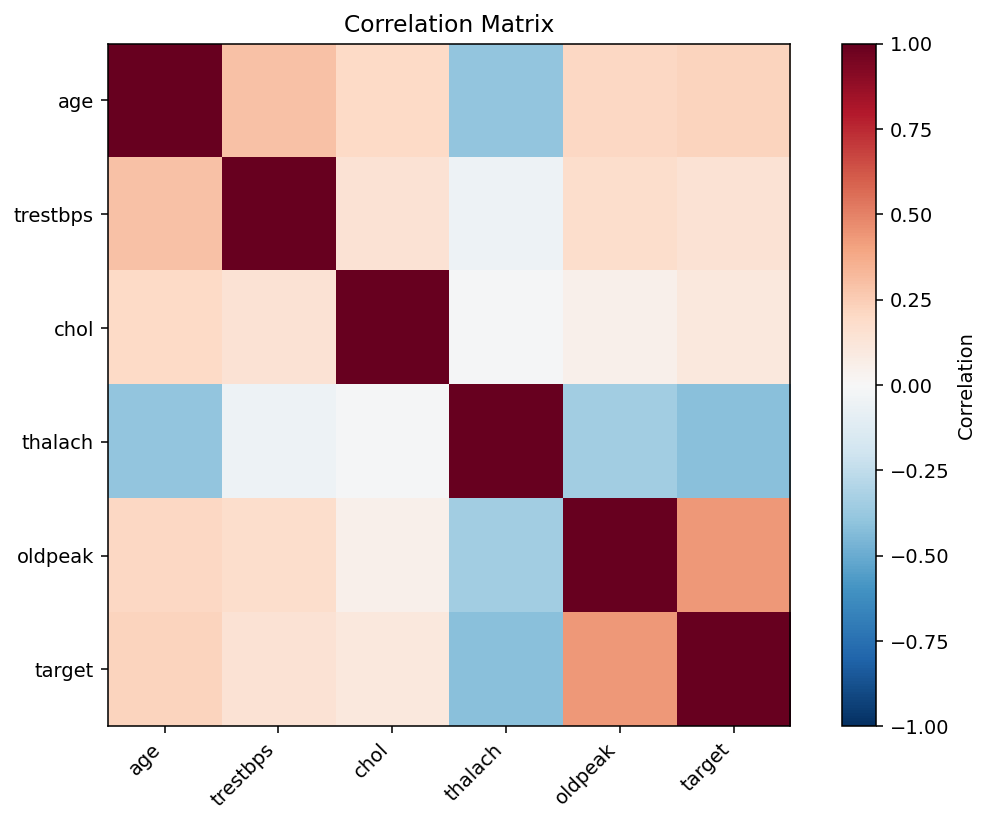

In [8]:
from IPython.display import Image, display
display(Image('output/figures/06_correlation_matrix.png'))


Figure 6: Correlation matrix. This heatmap shows relationships between numeric features and the target, especially oldpeak and thalach.


### Figure 7


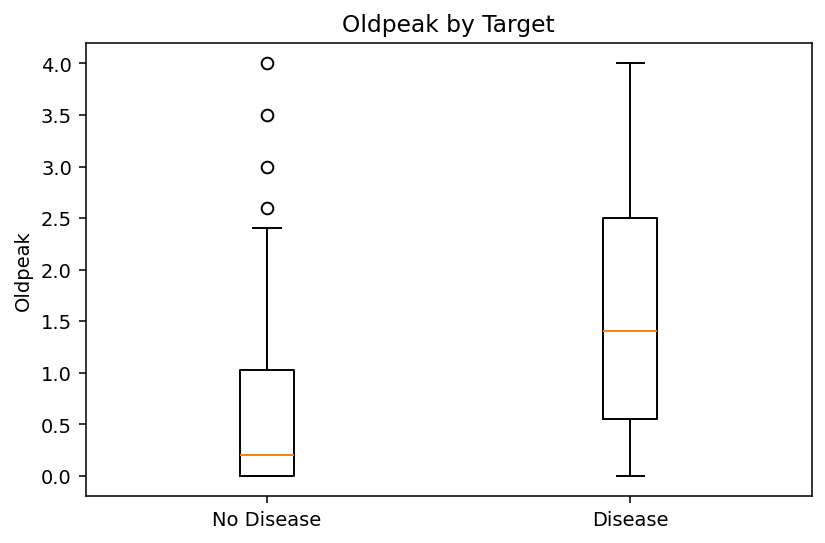

In [9]:
from IPython.display import Image, display
display(Image('output/figures/07_oldpeak_boxplot.png'))


Figure 7: Oldpeak by target. Higher oldpeak values are more common in heart disease cases, making it an important signal.


## Task 3: Data Cleaning and Preprocessing

The project uses a clear preprocessing plan:

- Remove duplicate rows.
- Convert numeric-looking values to numeric types.
- Fill missing numeric values using the median.
- Fill missing categorical values using the mode.
- Cap numeric outliers using the IQR method.
- Convert the original multi-class target into a binary target.
- Use one-hot encoding for categorical features.
- Use scaling for numeric features before Logistic Regression and SVM.

IQR means **Interquartile Range**. Q1 is the 25th percentile and Q3 is the 75th percentile. IQR is calculated as `Q3 - Q1`. Values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are treated as outliers and capped.


In [10]:
clean_df = pd.read_csv('heart_disease_cleaned.csv')
print('Cleaned dataset shape:', clean_df.shape)
print('Missing values after cleaning:', int(clean_df.isna().sum().sum()))
print('Target distribution:', clean_df['target'].value_counts().sort_index().to_dict())
clean_df.head()


Cleaned dataset shape: (303, 21)
Missing values after cleaning: 0
Target distribution: {0: 164, 1: 139}


 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target_raw  target age_group  cholesterol_risk  bp_risk  heart_rate_gap  oldpeak_high  risk_count
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0           0       0    senior                 0        1             7.0             1         2.0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0           2       1     older                 1        1            45.0             0         3.0
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0           1       1     older                 0        0            24.0             1         2.0
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0           0       0     young                 1        0            -4.0             1         2.0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0

## Task 4: Feature Engineering

Feature engineering means creating new useful columns from existing columns so the model can learn patterns more easily. The engineered features are:

- `age_group`: groups patients by age range.
- `cholesterol_risk`: 1 if cholesterol is at least 240.
- `bp_risk`: 1 if resting blood pressure is at least 140.
- `heart_rate_gap`: calculated as `220 - age - thalach`.
- `oldpeak_high`: 1 if oldpeak is at least 2.
- `risk_count`: combines multiple simple risk indicators.


In [11]:
new_features = ['age_group', 'cholesterol_risk', 'bp_risk', 'heart_rate_gap', 'oldpeak_high', 'risk_count']
clean_df[new_features].head()


age_group  cholesterol_risk  bp_risk  heart_rate_gap  oldpeak_high  risk_count
   senior                 0        1             7.0             1         2.0
    older                 1        1            45.0             0         3.0
    older                 0        0            24.0             1         2.0
    young                 1        0            -4.0             1         2.0
    young                 0        0             7.0             0         0.0

## Task 5: Machine Learning Models

Three models were trained and compared:

**Logistic Regression:** A simple and interpretable model that assigns weights to features and predicts the chance of heart disease.

**Random Forest:** An ensemble model that combines many decision trees. It often works well because multiple trees reduce the risk of relying on one weak decision path.

**Support Vector Machine:** A model that tries to find the best boundary between disease and no disease patients. SVM is useful for smaller classification datasets.


## Task 6: Model Evaluation

The models were compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrix.

- **Accuracy:** total correct predictions.
- **Precision:** when the model predicts heart disease, how often it is correct.
- **Recall:** how many real heart disease patients the model finds.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model separates disease and no disease classes.

For this medical task, **recall is very important** because false negatives are risky.


In [12]:
with open('output/model_metrics.json', 'r', encoding='utf-8') as file:
    metrics = json.load(file)

engineered_metrics = pd.DataFrame(metrics['engineered']).T[['accuracy','precision','recall','f1','roc_auc']]
engineered_metrics


                       accuracy precision  recall      f1 roc_auc
Logistic Regression      0.8689    0.8333  0.8929  0.8621  0.9675
Random Forest            0.9344       0.9  0.9643   0.931  0.9724
Support Vector Machine   0.8689    0.8333  0.8929  0.8621   0.961

In [13]:
print('Best model:', metrics['best_model'])
for model_name, row in metrics['engineered'].items():
    print(f"{model_name}: confusion_matrix={row['confusion_matrix']}, accuracy={row['accuracy']}, recall={row['recall']}, f1={row['f1']}, roc_auc={row['roc_auc']}")


Best model: Random Forest
Logistic Regression: confusion_matrix=[[28, 5], [3, 25]], accuracy=0.8689, recall=0.8929, f1=0.8621, roc_auc=0.9675
Random Forest: confusion_matrix=[[30, 3], [1, 27]], accuracy=0.9344, recall=0.9643, f1=0.931, roc_auc=0.9724
Support Vector Machine: confusion_matrix=[[28, 5], [3, 25]], accuracy=0.8689, recall=0.8929, f1=0.8621, roc_auc=0.961


**Best selected model:** Random Forest

Random Forest was selected because it achieved the strongest overall performance, including high recall and F1-score. In a hospital problem, recall matters because missing a patient who may have heart disease is more dangerous than raising a cautious warning.


## Task 7: Model Interpretation

Feature importance helps explain which inputs influenced the model most. This is important because a medical model should not be treated as a black box.


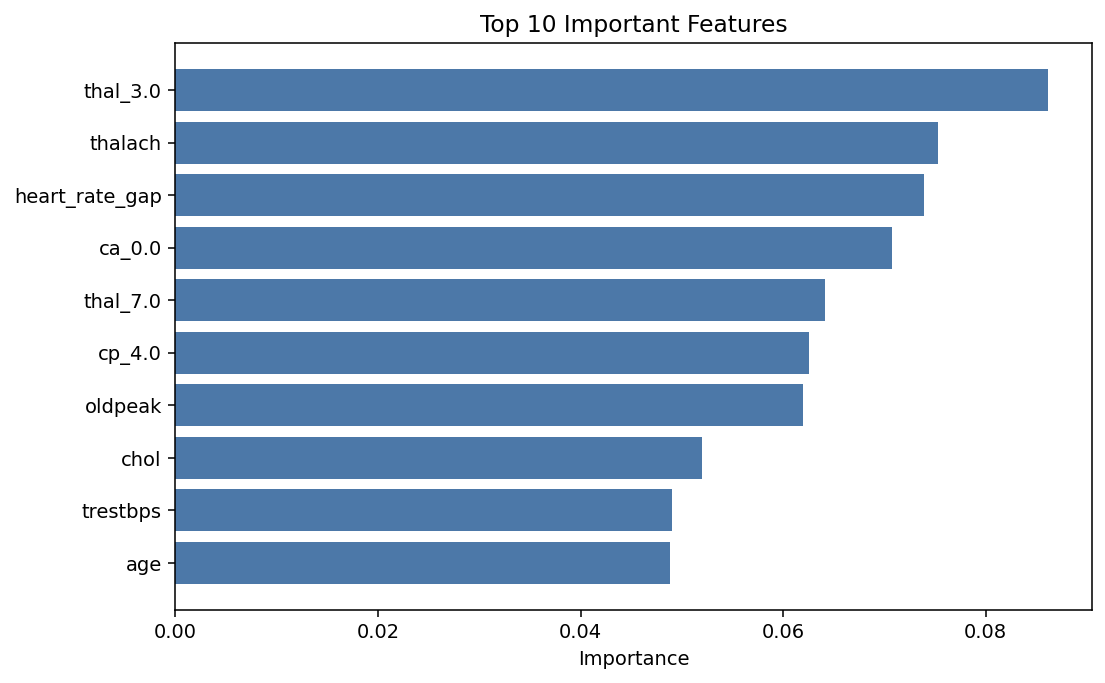

In [14]:
from IPython.display import Image, display
display(Image('output/figures/08_feature_importance.png'))


In [15]:
top_features = pd.read_csv('output/top_10_feature_importance.csv')
top_features


       feature  importance
      thal_3.0    0.086159
       thalach    0.075267
heart_rate_gap    0.073873
        ca_0.0    0.070718
      thal_7.0    0.064121
        cp_4.0    0.062558
       oldpeak    0.062013
          chol    0.051959
      trestbps    0.049034
           age    0.048840

## Task 8: AI-Assisted Development Reflection

AI was used as a support tool during the project, but the final choices were checked and modified for this exam project.

| Prompt | Useful AI Output | My Modification |
|---|---|---|
| Read the exam instruction PDF and list required tasks. | AI identified the required sections and files. | I followed the required tasks in the notebook, script, report, and prompt history. |
| Find a suitable heart disease dataset. | AI suggested the UCI Cleveland Heart Disease dataset. | I used the official UCI data and converted the target into binary classification. |
| Write simple ML code for cleaning, EDA, models, and evaluation. | AI suggested pandas, matplotlib, and scikit-learn pipelines. | I kept the code simple and added Logistic Regression, Random Forest, and SVM. |
| Create final report sections. | AI helped organize report sections. | I used the actual model results from my script and added deployment explanation. |

**AI mistakes noticed:** AI first suggested some complex ideas that were not needed for a beginner final exam project.

**Improvements made:** I used an official dataset source, added clear feature engineering, used real model metrics, and explained every major step.


## Task 9: Critical Discussion and Recommendations

**Limitations:** The dataset is small and old, so the results may not generalize to all hospital patients.

**Bias risk:** Bias can happen if the dataset does not represent the real population. A hospital should test the model on newer local patient data before real use.

**Data leakage prevention:** The project uses train/test splitting and scikit-learn pipelines so preprocessing is fitted inside the training workflow.

**Ethics and privacy:** Patient data must be protected, anonymized, and used only with permission. The model should support doctors, not replace doctors.

**Deployment recommendation:** The Streamlit app is useful for academic demonstration, but a real hospital deployment would need validation, monitoring, privacy controls, clinical review, and secure data handling.


## Streamlit Web App and Functionality

The deployed app link is: https://heartdiseaseaimllabfinal.streamlit.app/

The website provides:

- Model summary metrics at the top.
- A single-patient form with readable medical labels.
- Prediction result with disease-risk label and probability.
- Patient summary table.
- Technical values sent to the model.
- Multi-patient table input for batch prediction.
- Downloadable CSV prediction results.


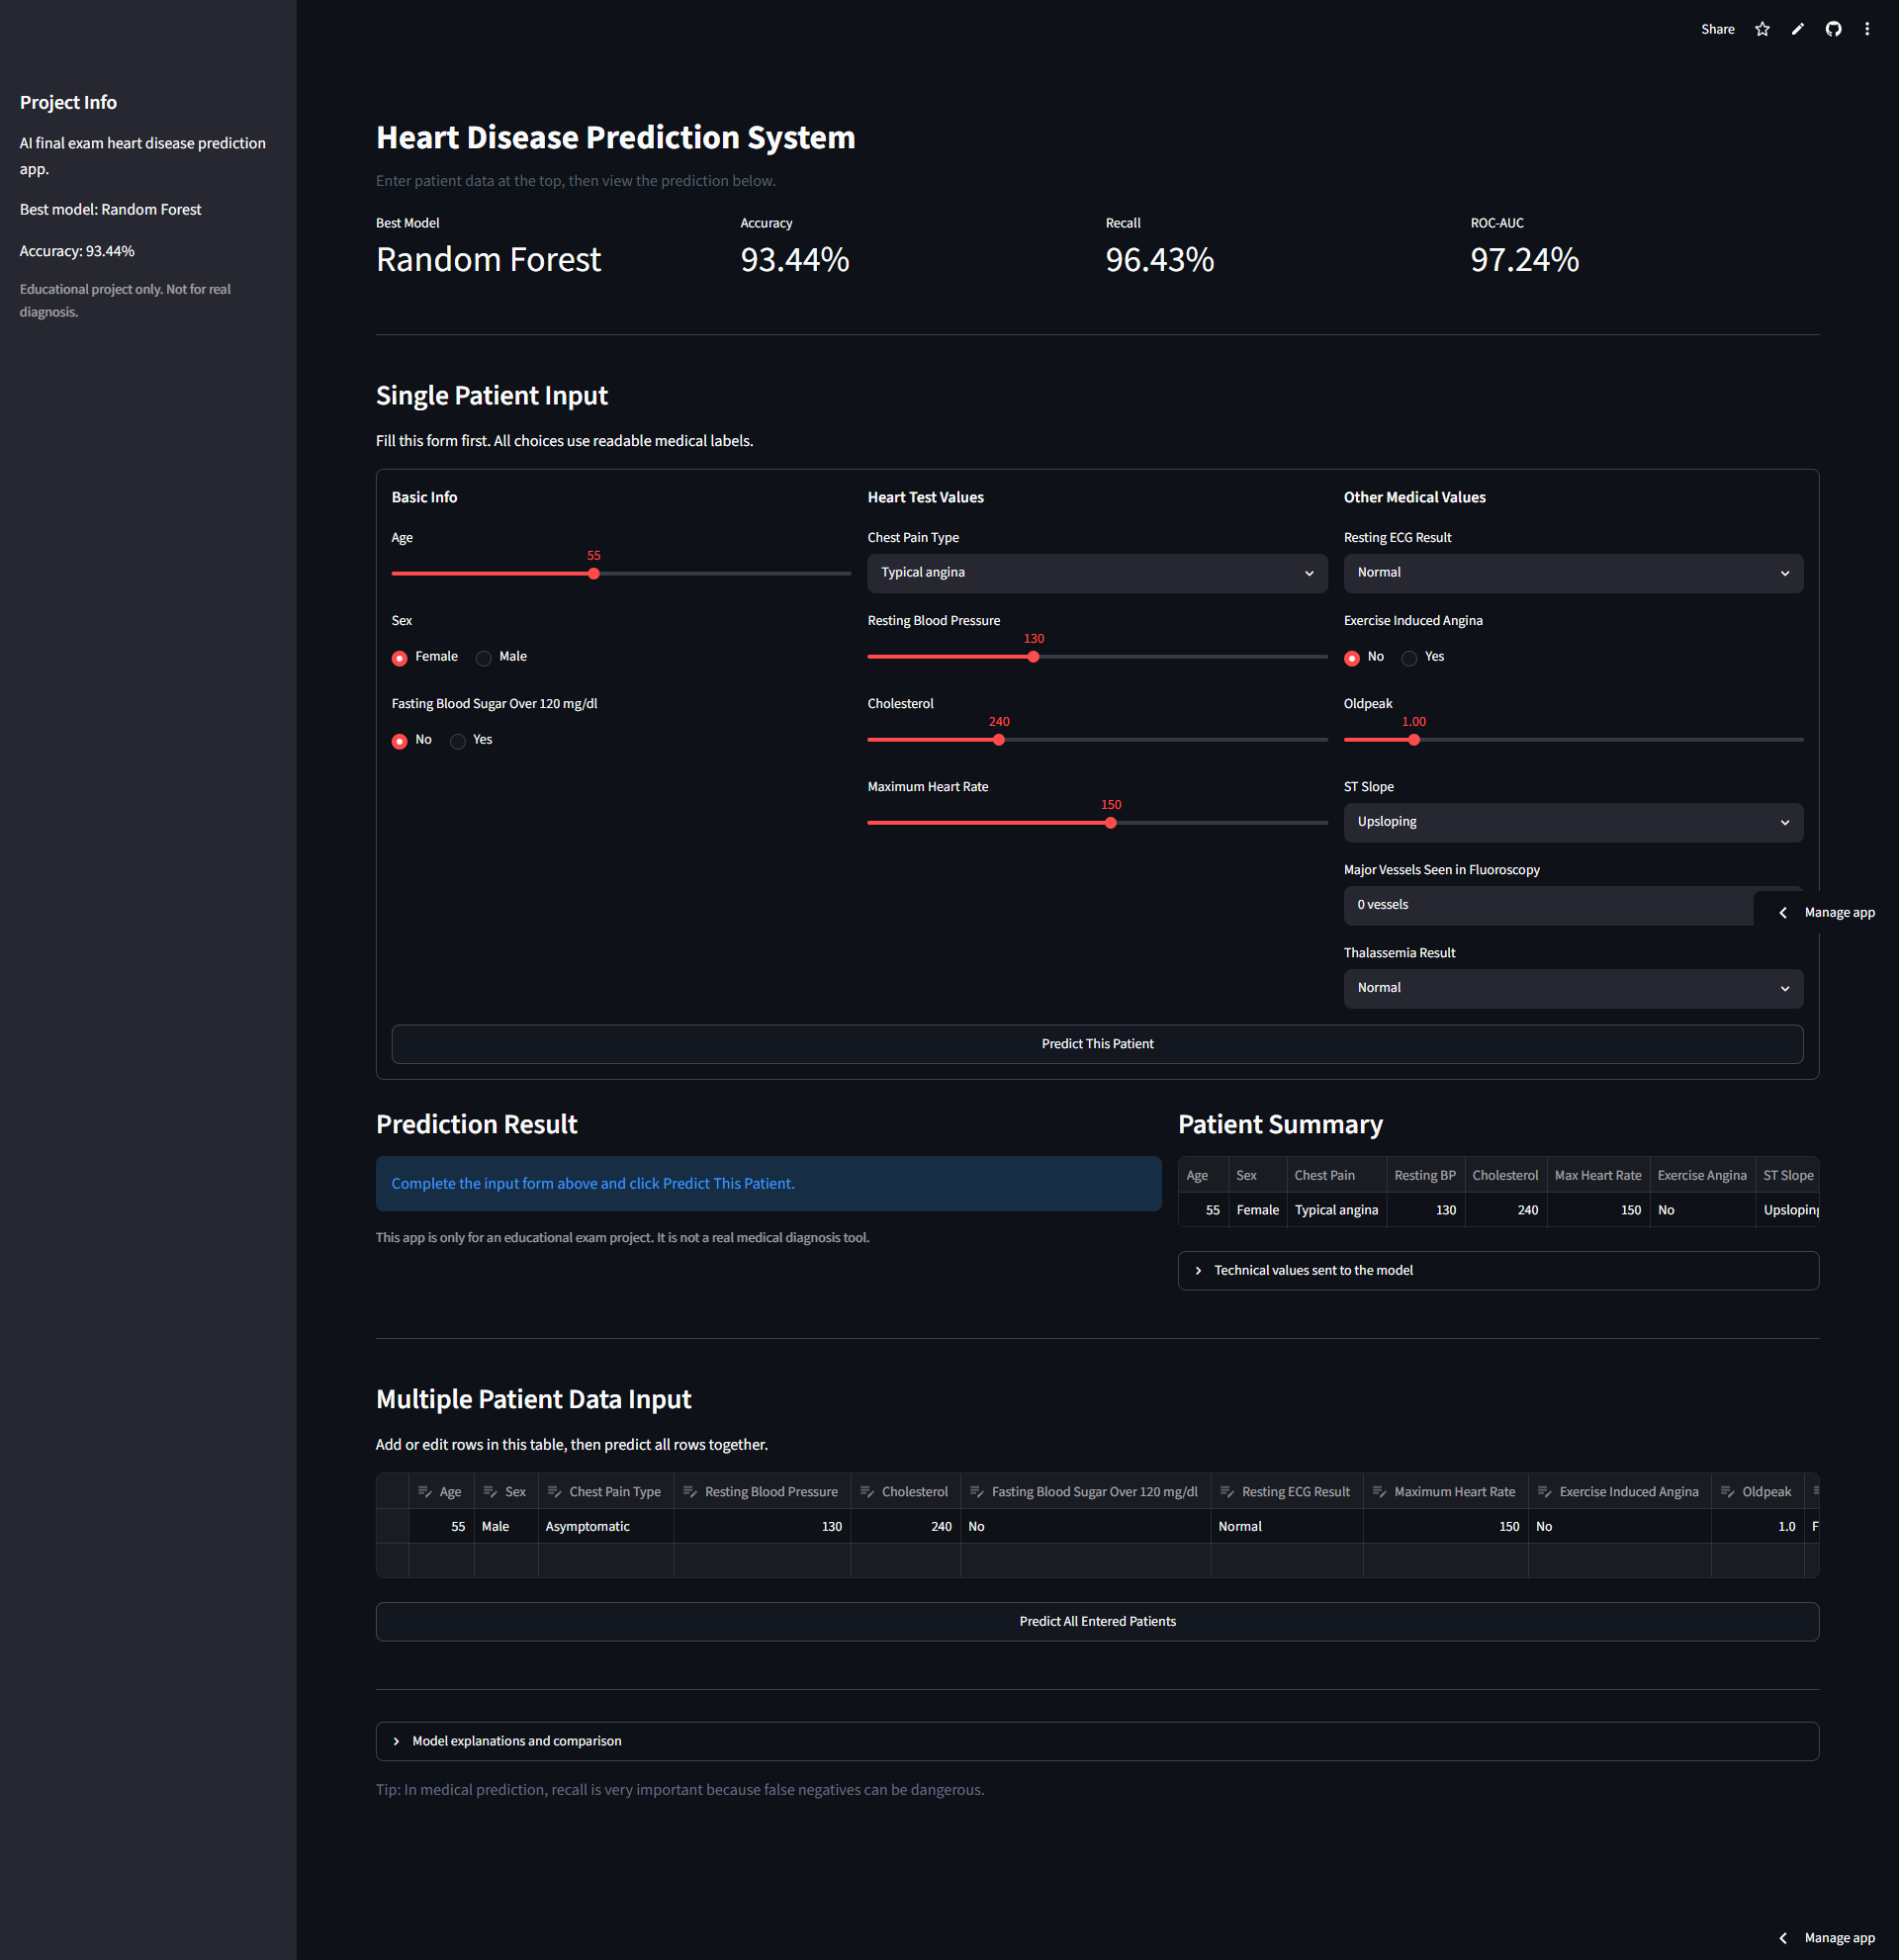

In [16]:
from IPython.display import Image, display
display(Image('screencapture-heartdiseaseaimllabfinal-streamlit-app-2026-07-08-22_07_54.png'))


### How the Streamlit App Works

`streamlit_app.py` loads the cleaned dataset and saved model metrics. The function `load_model()` builds the preprocessing and Random Forest pipeline, trains it on `heart_disease_cleaned.csv`, and caches it with `st.cache_resource`. This keeps the app fast because the model is not rebuilt every time the page refreshes.

For single-patient prediction, the user selects values in the form and clicks **Predict This Patient**. The app converts readable labels into numeric model values, creates a one-row DataFrame, adds engineered features, then calls `model.predict()` and `model.predict_proba()`.

For batch prediction, the editable table accepts multiple patient rows. The app converts readable rows into model-ready columns, adds engineered features for every row, predicts all rows, displays the results, and allows downloading the results as a CSV file.


## Reproducibility

To regenerate all outputs, run:

```bash
python final_exam_heart_disease.py
```

This recreates the cleaned CSV, EDA figures, model metrics, best model file, feature-importance table, final PDF report, and prompt-history file. The submitted notebook is already saved with outputs and should be kept as the final notebook artifact.
